# Synthetic Difference-in-Differences: California Proposition 99

Replicates the R `synthdid` starter code in Python:

```r
library(synthdid)
data('california_prop99')
setup = panel.matrices(california_prop99)
tau.hat = synthdid_estimate(setup$Y, setup$N0, setup$T0)
se = sqrt(vcov(tau.hat, method='placebo'))
sprintf('point estimate: %1.2f', tau.hat)
sprintf('95%% CI (%1.2f, %1.2f)', tau.hat - 1.96 * se, tau.hat + 1.96 * se)
plot(tau.hat)
```

**Dataset:** California Prop 99 (tobacco tax, 1989). Outcome is cigarette consumption (packs per capita). Treatment effect should be approximately -15 to -16 packs per capita.

## 1. Setup

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from synthdid import synthdid_estimate, panel_matrices

## 2. Load data

## 3. Estimate


In [3]:
DATA_PATH = os.path.join(os.getcwd(), "..", "data", "california_prop99.csv")
df = pd.read_csv(DATA_PATH, sep=None, engine="python")

setup = panel_matrices(df, unit="State", time="Year",
                       outcome="PacksPerCapita", treatment="treated")

est = synthdid_estimate(
    setup["Y"], setup["N0"], setup["T0"],
    unit_names=setup["unit_names"],
    time_names=[str(t) for t in setup["time_names"]],
)
est

SynthdidEstimate(tau=-15.6038, n_units=39, n_control=38, n_treated=1, n_pre=19, n_post=12)

### Results summary

`.summary()` computes the SE via the placebo method and returns a formatted table.

In [4]:
results = est.summary(se_method="placebo", replications=200)
print(results)

            Synthetic Difference-in-Differences             
 No. Units:                 39  SE Method:       placebo    
 No. Periods:               31  Replications:        200    
 No. Control Units:         38  Conf. Level:         95%    
 No. Treated Units:          1                              
 Pre-treatment Periods:     19                              
 Post-treatment Periods:    12                              
------------------------------------------------------------
                 coef   std err         z     P>|z|
------------------------------------------------------------
 tau         -15.6038    9.6343   -1.6196    0.1053
------------------------------------------------------------
 95% Conf. Interval:  [-34.4871,   3.2794]


### Plot

/home/me/work/synthdid_python/examples/../synthdid/plot.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


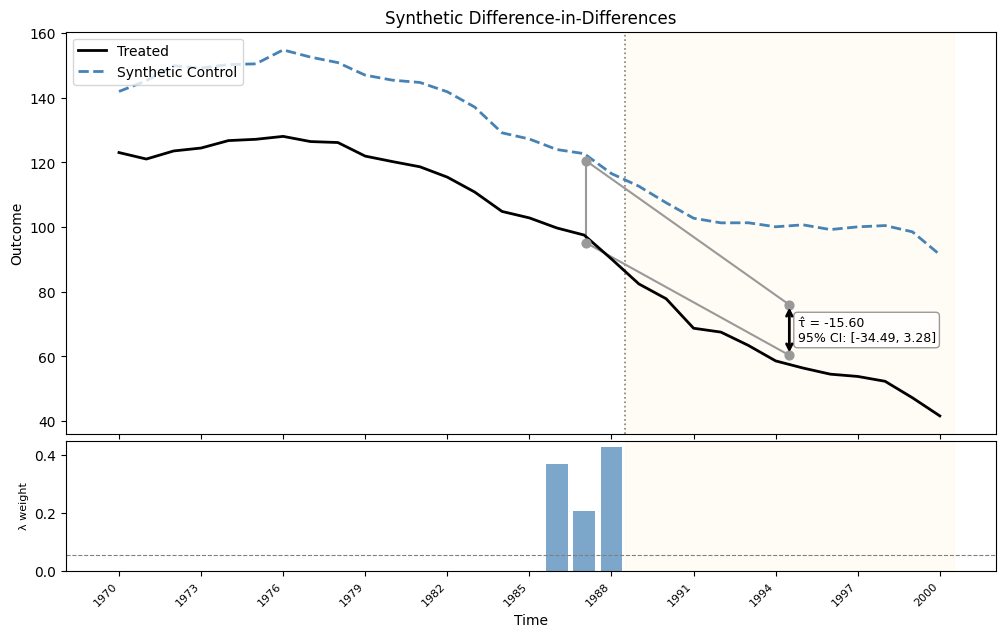

In [5]:
fig = est.plot(se=results.se, figsize=(12, 7))
plt.show()

### Weight importance

In [6]:
est.top_weights(top_n=10, weight_type="omega").round(4)

,estimate 1
Nevada,0.1245
New Hampshire,0.1050
Connecticut,0.0783
Delaware,0.0704
Colorado,0.0575
Illinois,0.0534
Nebraska,0.0479
Montana,0.0451
Utah,0.0415
New Mexico,0.0406


In [7]:
est.top_weights(top_n=5, weight_type="lambda").round(4)

,estimate 1
1988,0.4271
1986,0.3665
1987,0.2065
1985,0.0000
1984,0.0000


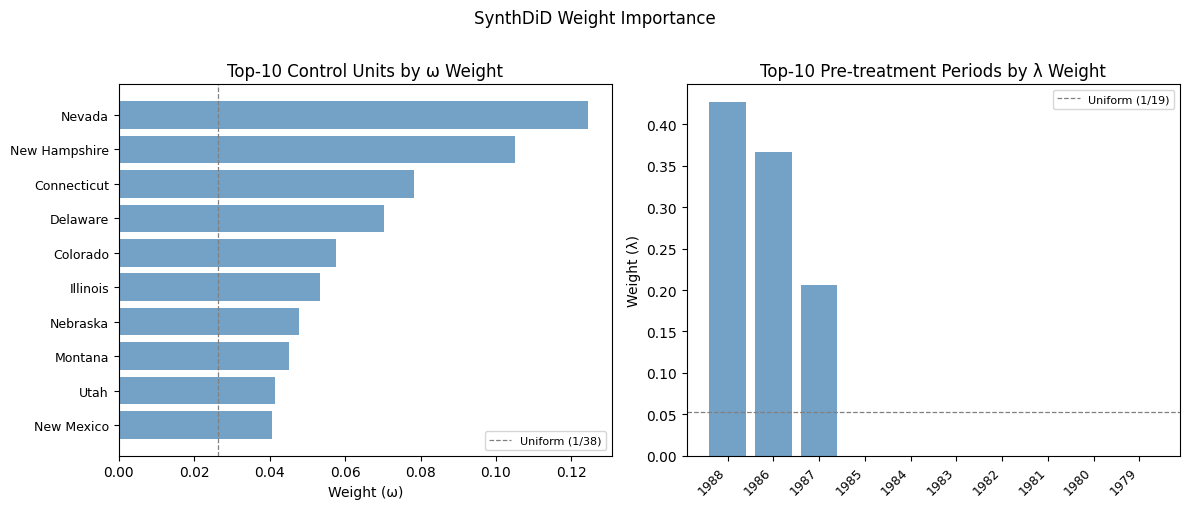

In [8]:
fig = est.weights_plot(top_n=10)
plt.show()

### Period-by-period effect curve

In [9]:
detail = est.effect_curve(detail=True)
import pandas as pd
pd.DataFrame({
    "actual":    detail.actual.round(2),
    "predicted": detail.predicted.round(2),
    "tau(t)":    detail.tau.round(2),
}, index=detail.time_names)

,actual,predicted,tau(t)
1989,82.4,87.24,-4.84
1990,77.8,82.13,-4.33
1991,68.7,77.35,-8.65
1992,67.5,75.92,-8.42
1993,63.4,75.95,-12.55
1994,58.6,74.71,-16.11
1995,56.4,75.31,-18.91
1996,54.5,73.85,-19.35
1997,53.8,74.68,-20.88
1998,52.3,75.08,-22.78
